In [29]:
import pandas as pd
import pyarrow 
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader , Dataset
from sklearn.model_selection import train_test_split

In [30]:
con = duckdb.connect()

df = con.execute("""
SELECT X_jets_LR, X_jets
FROM '/Volumes/falcon/gsoc_2026/data/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet'
""").fetch_df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [32]:
def build_images(arr):
    images = []
    for x in arr:
    # stack rows inside each channel
        channels = [np.stack(row) for row in x]
        img = np.stack(channels, axis=-1)  # (H,W,3)
        images.append(img)
    return np.stack(images)

In [33]:
X_LR = build_images(df["X_jets_LR"].values)
X_HR = build_images(df["X_jets"].values)

print(X_LR.shape, X_HR.shape)

(55494, 64, 64, 3) (55494, 125, 125, 3)


In [34]:
X_LR = X_LR.astype(np.float32)
X_HR = X_HR.astype(np.float32)

In [35]:
print("LR NaNs:", np.isnan(X_LR).sum())
print("HR NaNs:", np.isnan(X_HR).sum())

print("LR range:", X_LR.min(), X_LR.max())
print("HR range:", X_HR.min(), X_HR.max())

LR NaNs: 0
HR NaNs: 0
LR range: -3.8294892 18914.906
HR range: -8.273462 75659.625


In [ ]:
X_LR = X_LR.astype(np.float32)
X_HR = X_HR.astype(np.float32)


X_LR = np.maximum(X_LR, 0)
X_HR = np.maximum(X_HR, 0)


#  STRONG LOG COMPRESSION

X_LR = np.log1p(X_LR)
X_HR = np.log1p(X_HR)


# PERCENTILE NORMALIZATION 

lr_scale = np.percentile(X_LR, 99)
hr_scale = np.percentile(X_HR, 99)

X_LR /= (lr_scale + 1e-8)
X_HR /= (hr_scale + 1e-8)


# clip outliers

X_LR = np.clip(X_LR, 0, 1)
X_HR = np.clip(X_HR, 0, 1)


X_LR = X_LR * 2 - 1
X_HR = X_HR * 2 - 1

In [37]:
print("NaNs LR:", np.isnan(X_LR).sum())
print("NaNs HR:", np.isnan(X_HR).sum())

print("Range LR:", X_LR.min(), X_LR.max())
print("Range HR:", X_HR.min(), X_HR.max())

NaNs LR: 0
NaNs HR: 0
Range LR: -1.0 1.0
Range HR: -1.0 1.0


In [38]:
X_LR = np.transpose(X_LR, (0,3,1,2))   # (N,3,64,64)
X_HR = np.transpose(X_HR, (0,3,1,2))   # (N,3,125,125)

In [39]:
X_LR_train, X_LR_temp, X_HR_train, X_HR_temp = train_test_split(
    X_LR, X_HR, test_size=0.2, random_state=42
)

X_LR_val, X_LR_test, X_HR_val, X_HR_test = train_test_split(
    X_LR_temp, X_HR_temp, test_size=0.5, random_state=42
)

In [40]:
np.savez_compressed(
    "jets_sr_preprocessed.npz",
    X_LR_train=X_LR_train,
    X_HR_train=X_HR_train,
    X_LR_val=X_LR_val,
    X_HR_val=X_HR_val,
    X_LR_test=X_LR_test,
    X_HR_test=X_HR_test
)

In [41]:
img_lr=X_LR_train[0]
img_hr=X_HR_train[0]

In [ ]:
img_lr = img_lr.transpose(1,2,0)  # (64,64,3)
img_hr = img_hr.transpose(1,2,0)  # (125,125,3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


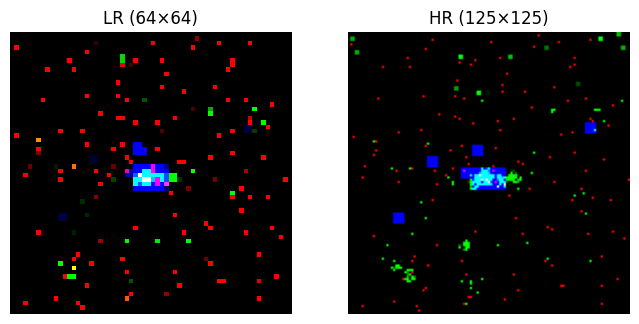

In [43]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_lr)
plt.title("LR (64×64)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_hr)
plt.title("HR (125×125)")
plt.axis("off")

plt.show()